<a href="https://colab.research.google.com/github/ilyasstop500/-SYS-INT-/blob/main/Weather_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset
import datetime
import kagglehub

In [2]:
file_path = kagglehub.dataset_download("guillemservera/global-daily-climate-data")


100%|██████████| 213M/213M [00:04<00:00, 50.4MB/s]

Extracting files...


In [3]:


# Assuming file as the following columns :
# 'station_id', 'city_name', 'date', 'season',
# 'avg_temp_c', 'min_temp_c', 'max_temp_c',
# 'precipitation_mm', 'snow_dapth_mm',
# 'avg_wind_dir_deg', 'avg_wind_speed_kmh', 'peak_wind_gust_kmh',a
# 'avg_sea_level_pres_hpa',
# 'sunshine_total_min'
class WeatherDataset(Dataset):
    def __init__(self, file_path, src_cities, tgt_cities, src_columns, tgt_columns, sequence_length=7, dtime=1):
        self.dataframe = pd.read_parquet(file_path)

        self.X = self.dataframe[self.dataframe['city_name'].isin(src_cities)][['city_name', 'date'] + src_columns]
        self.src_cities = src_cities
        self.src_columns = src_columns

        self.Y = self.dataframe[self.dataframe['city_name'].isin(tgt_cities)][['city_name', 'date'] + tgt_columns]
        self.tgt_cities = tgt_cities
        self.tgt_columns = tgt_columns

        self.sequence_length = sequence_length
        self.dtime = dtime

        # Limit dataframes to value that have all columns not nan
        self.X = self.X[np.logical_not(self.X[src_columns].isna().T.any())]
        self.Y = self.Y[np.logical_not(self.Y[tgt_columns].isna().T.any())]

        # Convert date to int (proleptic Gregorian ordinal)
        self.X['date'] = self.X['date'].apply(lambda date: date.date().toordinal())
        self.Y['date'] = self.Y['date'].apply(lambda date: date.date().toordinal())

        # Change category so that the ordering function (.sort_values) will order cities as we want
        self.X['city_name'] = self.X['city_name'].cat.set_categories(self.src_cities, ordered=True)
        self.Y['city_name'] = self.Y['city_name'].cat.set_categories(self.tgt_cities, ordered=True)


        # Limit dataframe to date that's compatible with sequence_length and dtime
        # Create a ordered list of valid date => date with sequence_length value
        self.valid_date = []
        for date in range(self.X['date'].min() + sequence_length, self.X['date'].max()):
            if any(self.X[self.X['date'] == date - dj]['city_name'].count() != src_cities.__len__() for dj in range(sequence_length)):
                continue
            if self.Y[self.Y['date'] == date + self.dtime]['city_name'].count() != tgt_cities.__len__():
                continue
            self.valid_date.append(date)

        # shape (#value, (len(X), len(Y))
        self.shape = (self.valid_date.__len__(),
                      (self.sequence_length * self.src_cities.__len__() * self.src_columns.__len__(),
                       self.tgt_cities.__len__() * self.tgt_columns.__len__()))
        self.input_size = self.sequence_length * self.src_cities.__len__() * self.src_columns.__len__()


    def __len__(self):
        return self.valid_date.__len__()

    # X => 1d ndarray [v[d1, c1, v1], v[d1, c1, v2], ..., v[d1, c2, v1], ..., v[d2, c1, v1]...] (di day, ci city, vi column)
    # Y => 1d ndarray [v[c1, v1], v[c1, v2], ..., v[c2, v1], ...] (ci city, vi column)
    def __getitem__(self, idx):
        date = self.valid_date[idx]
        X = self.X[self.X['date'].between(date - self.sequence_length + 1, date + 1)]
        Y = self.Y[self.Y['date'] == date + self.dtime]
        X = np.asarray(X.sort_values(by=['date', 'city_name'])[self.src_columns]).flatten()
        Y = np.asarray(Y.sort_values(by=['city_name'])[self.tgt_columns]).flatten()

        # Pad X with zeros if it's shorter than input_size
        if len(X) < self.input_size:
            X = np.pad(X, (0, self.input_size - len(X)), 'constant', constant_values=0)
        # Truncate X if it's longer than input_size
        elif len(X) > self.input_size:
            X = X[:self.input_size]

        return X, Y

# **CLASSIC NEURAL NETWORK**

In [4]:
dataset = WeatherDataset(file_path+"/daily_weather.parquet",
                          ['Strasbourg'],
                          ['Strasbourg'],
                          ['avg_temp_c', 'min_temp_c', 'max_temp_c'],
                          ['avg_temp_c', 'min_temp_c', 'max_temp_c'],
                          7, 1)
print(dataset.__len__())
print("DatasetX")
print(dataset.X)
print("DatasetY")
print(dataset.Y)

19046
DatasetX
        city_name    date  avg_temp_c  min_temp_c  max_temp_c
6235   Strasbourg  708663        11.8         6.1        16.1
6236   Strasbourg  708664        11.9         7.2        17.2
6238   Strasbourg  708666         5.7         2.2         8.9
6241   Strasbourg  708669         3.7        -2.2         7.8
6244   Strasbourg  708672         6.2         0.0        11.1
...           ...     ...         ...         ...         ...
36145  Strasbourg  738763        16.4        12.6        21.3
36146  Strasbourg  738764        17.5        12.3        23.6
36147  Strasbourg  738765        18.6        13.3        24.7
36148  Strasbourg  738766        18.1        14.4        22.5
36149  Strasbourg  738767        17.5        13.4        22.4

[19270 rows x 5 columns]
DatasetY
        city_name    date  avg_temp_c  min_temp_c  max_temp_c
6235   Strasbourg  708663        11.8         6.1        16.1
6236   Strasbourg  708664        11.9         7.2        17.2
6238   Strasbourg  7

In [8]:

# Sample test
Sample = dataset.__getitem__(0)
print(Sample[0])
print(Sample[1])
Sample2 = dataset.__getitem__(1)
print(Sample2[0])
print(Sample2[1])

[ 7.4  1.1 13.9  7.9 -1.1 16.1  9.7  5.  13.9  8.9  2.8 12.8  8.   0.
 12.8  9.2 -2.2 17.2 12.7  1.1 22.2]
[10.9  7.2 16.1]
[ 7.9 -1.1 16.1  9.7  5.  13.9  8.9  2.8 12.8  8.   0.  12.8  9.2 -2.2
 17.2 12.7  1.1 22.2 10.9  7.2 16.1]
[ 8.1  2.8 12.8]


In [19]:

from sklearn.model_selection import train_test_split

List_of_Samples = []
for k in range (dataset.__len__()):
    Sample = dataset.__getitem__(k)
    List_of_Samples.append(Sample)


print(List_of_Samples[0][0])
print(List_of_Samples[0][1])



# Assuming `samples` is a list of tuples (entries, results)
entries = [sample[0] for sample in List_of_Samples]  # Extract entries
results = [sample[1] for sample in List_of_Samples]  # Extract results

# Split the data into training and test sets
entries_train, entries_test, results_train, results_test = train_test_split(
    entries, results, test_size=0.2, random_state=42
)

# Optionally convert back to numpy arrays if needed
entries_train = np.array(entries_train)
entries_test = np.array(entries_test)
results_train = np.array(results_train)
results_test = np.array(results_test)
print(entries_train)

# Outputs
print("Training entries shape:", entries_train.shape)
print("Test entries shape:", entries_test.shape)
print("Training results shape:", results_train.shape)
print("Test results shape:", results_test.shape)
print("Total Sample Count:", dataset.__len__())


[ 7.4  1.1 13.9  7.9 -1.1 16.1  9.7  5.  13.9  8.9  2.8 12.8  8.   0.
 12.8  9.2 -2.2 17.2 12.7  1.1 22.2]
[10.9  7.2 16.1]
[[ 23.5  13.9  32.  ...  22.8  18.8  28.4]
 [ 17.2  10.2  27.4 ...  15.1   8.5  22.7]
 [ 13.   12.6  13.7 ...  14.8  12.   18.9]
 ...
 [  0.6  -2.2   2.  ... -10.7 -12.   -9.9]
 [ 16.1   9.8  23.2 ...  22.2  13.9  30.8]
 [ 17.2  11.7  22.4 ...  19.9  13.9  26.9]]
Training entries shape: (15236, 21)
Test entries shape: (3810, 21)
Training results shape: (15236, 3)
Test results shape: (3810, 3)
Total Sample Count: 19046


In [9]:

!pip install tensorflow


import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Define a custom accuracy metric
def custom_accuracy(y_true, y_pred):
    # Tolerance level for determining a correct prediction
    tolerance = 0.1  # Adjust this as needed
    # Check if the absolute difference is within the tolerance for all elements
    correct = tf.reduce_all(tf.abs(y_true - y_pred) < tolerance, axis=1)
    # Calculate the mean of correct predictions
    return tf.reduce_mean(tf.cast(correct, tf.float32))

# Define the model
model = Sequential()

# Input layer (21 input nodes) and first hidden layer
model.add(Dense(128, input_dim=21, activation='relu'))

# Second hidden layer
model.add(Dense(64, activation='relu'))

# Output layer (3 output nodes)
model.add(Dense(3))

# Compile the model with the custom accuracy
model.compile(optimizer='adam', loss='mse', metrics=[custom_accuracy])

# Train the model
history = model.fit(
    entries_train,
    results_train,
    validation_data=(entries_test, results_test),
    epochs=50,  # Number of epochs
    batch_size=32,  # Number of samples per gradient update
    verbose=1  # Prints progress during training
)




Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


477/477 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - custom_accuracy: 5.3714e-05 - loss: 14.0800 - val_custom_accuracy: 0.0000e+00 - val_loss: 6.8514
Epoch 2/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - custom_accuracy: 3.2475e-04 - loss: 6.7628 - val_custom_accuracy: 0.0000e+00 - val_loss: 6.4832
Epoch 3/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - custom_accuracy: 0.0000e+00 - loss: 6.7145 - val_custom_accuracy: 0.0000e+00 - val_loss: 7.6780
Epoch 4/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - custom_accuracy: 1.3299e-04 - loss: 6.7223 - val_custom_accuracy: 2.6042e-04 - val_loss: 6.3803
Epoch 5/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - custom_accuracy: 3.7049e-05 - loss: 6.4252 - val_custom_accuracy: 2.6042e-04 - val_loss: 6.3730
Epoch 6/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - custom_accuracy: 6.1951e-05 - loss: 6.4324 - val_custom_accuracy: 2.6042e-04 - val_loss: 7.3555
Epoch 7/50
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - custom_accuracy: 1.2427e-04 - loss: 6.3492 - val_custom_

In [10]:
predictions = model.predict(entries_test)


120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


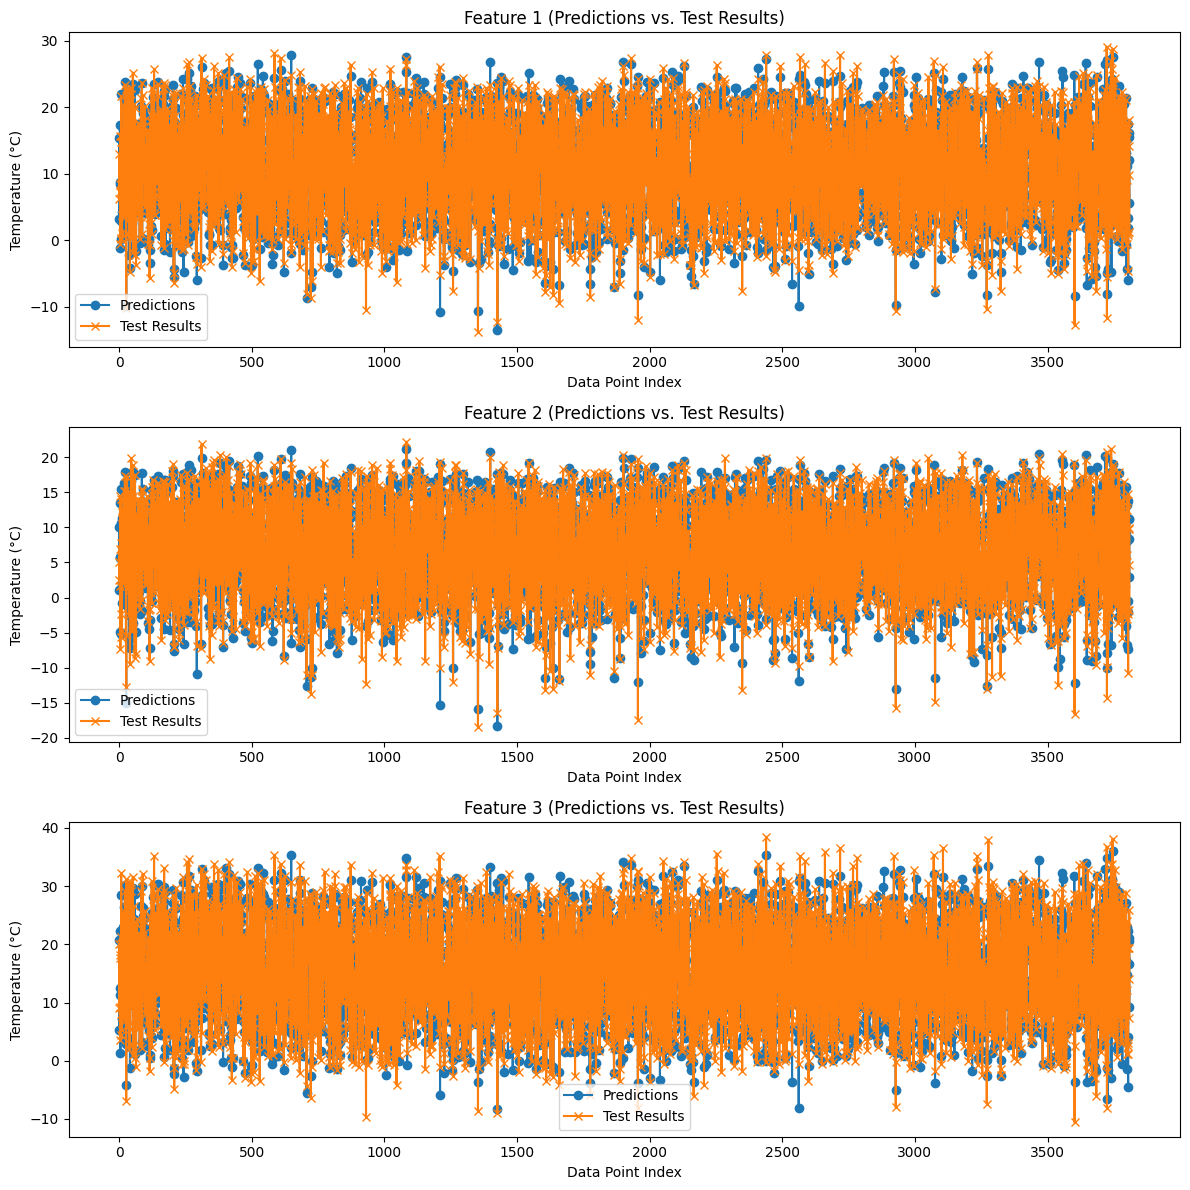

In [11]:
import matplotlib.pyplot as plt

# Assuming 'predictions' and 'results_test' are available

# Create a figure with 3 rows and 1 column of subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 12))  # Adjust figsize as needed

# Iterate through the 3 output features (avg_temp_c, min_temp_c, max_temp_c)
for i in range(3):
    # Plot predictions and test results as lines
    axes[i].plot(predictions[:, i], label="Predictions", marker='o')  # Predictions in blue with circle markers
    axes[i].plot(results_test[:, i], label="Test Results", marker='x')  # Test results in orange with x markers

    axes[i].set_xlabel("Data Point Index")  # X-axis label
    axes[i].set_ylabel("Temperature (°C)")  # Y-axis label (assuming temperature is the output)
    axes[i].set_title(f"Feature {i+1} (Predictions vs. Test Results)")
    axes[i].legend()  # Show legend to distinguish lines

# Adjust spacing between subplots
plt.tight_layout()
plt.show()


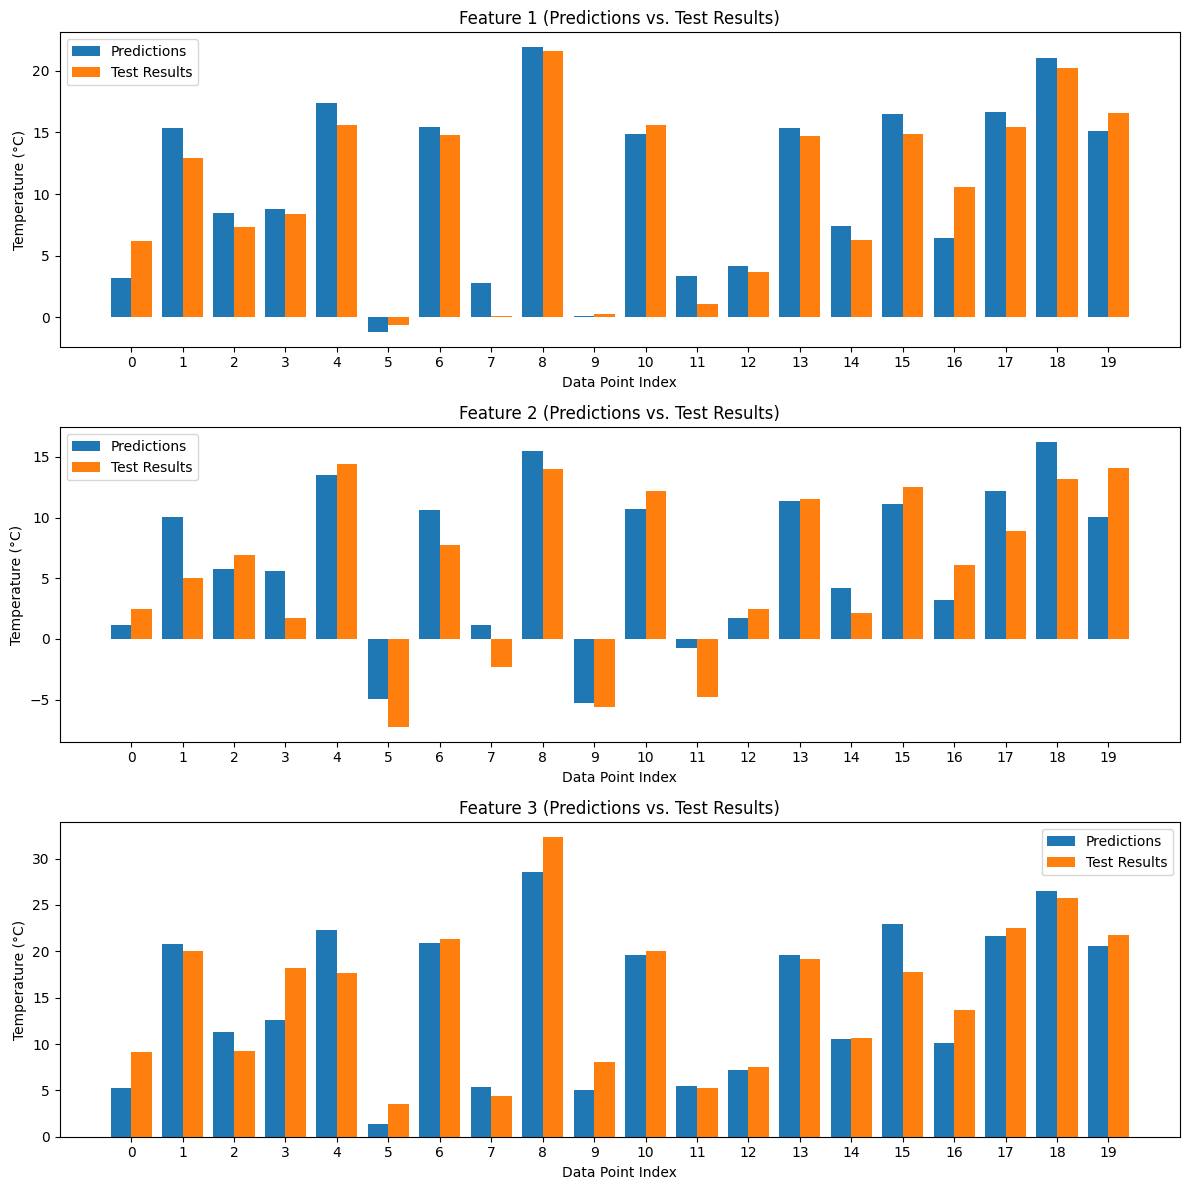

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'predictions' and 'results_test' are available

# Create a figure with 3 rows and 1 column of subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 12))  # Adjust figsize as needed

# Number of data points to display (adjust as needed)
num_data_points = 20

# X-axis values (data point indices)
x_values = np.arange(num_data_points)

# Iterate through the 3 output features (avg_temp_c, min_temp_c, max_temp_c)
for i in range(3):
    # Plot predictions and test results as bars
    axes[i].bar(x_values - 0.2, predictions[:num_data_points, i], width=0.4, label="Predictions")
    axes[i].bar(x_values + 0.2, results_test[:num_data_points, i], width=0.4, label="Test Results")

    axes[i].set_xlabel("Data Point Index")  # X-axis label
    axes[i].set_ylabel("Temperature (°C)")  # Y-axis label (assuming temperature is the output)
    axes[i].set_title(f"Feature {i+1} (Predictions vs. Test Results)")
    axes[i].legend()  # Show legend to distinguish bars
    axes[i].set_xticks(x_values)  # Set x-axis ticks

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

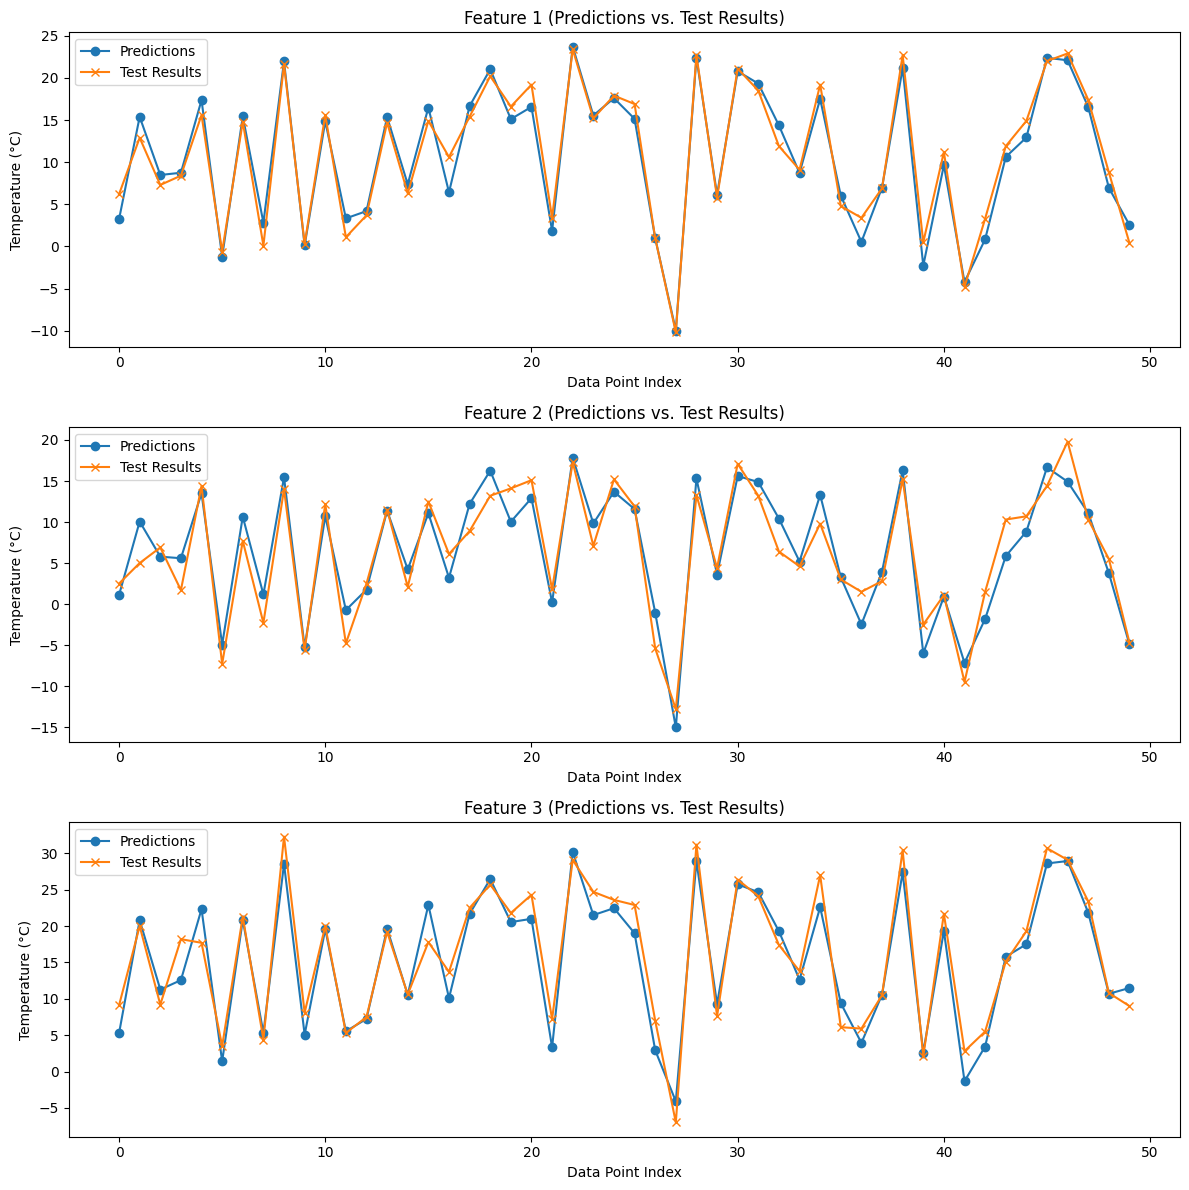

In [13]:
import matplotlib.pyplot as plt

# Assuming 'predictions' and 'results_test' are available

# Create a figure with 3 rows and 1 column of subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 12))  # Adjust figsize as needed

# Number of data points to display
num_data_points = 50

# Iterate through the 3 output features (avg_temp_c, min_temp_c, max_temp_c)
for i in range(3):
    # Plot predictions and test results as lines for the first 'num_data_points' values
    axes[i].plot(predictions[:num_data_points, i], label="Predictions", marker='o')
    axes[i].plot(results_test[:num_data_points, i], label="Test Results", marker='x')

    axes[i].set_xlabel("Data Point Index")  # X-axis label
    axes[i].set_ylabel("Temperature (°C)")  # Y-axis label (assuming temperature is the output)
    axes[i].set_title(f"Feature {i+1} (Predictions vs. Test Results)")
    axes[i].legend()  # Show legend to distinguish lines

# Adjust spacing between subplots
plt.tight_layout()
plt.show()

# **RNN - LSTM**

Train Entries Shape: (15236, 21, 1)
Train Results Shape: (15236, 3)
Epoch 1/3


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15236/15236 ━━━━━━━━━━━━━━━━━━━━ 126s 8ms/step - loss: 17.1466 - mae: 2.7669
Epoch 2/3
15236/15236 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 6.8617 - mae: 2.0485
Epoch 3/3
15236/15236 ━━━━━━━━━━━━━━━━━━━━ 126s 8ms/step - loss: 6.5880 - mae: 2.0053
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2214 - mae: 1.9376
Test Loss: 6.439321041107178, Test MAE: 1.973380446434021


IndexError: index 1 is out of bounds for axis 1 with size 1

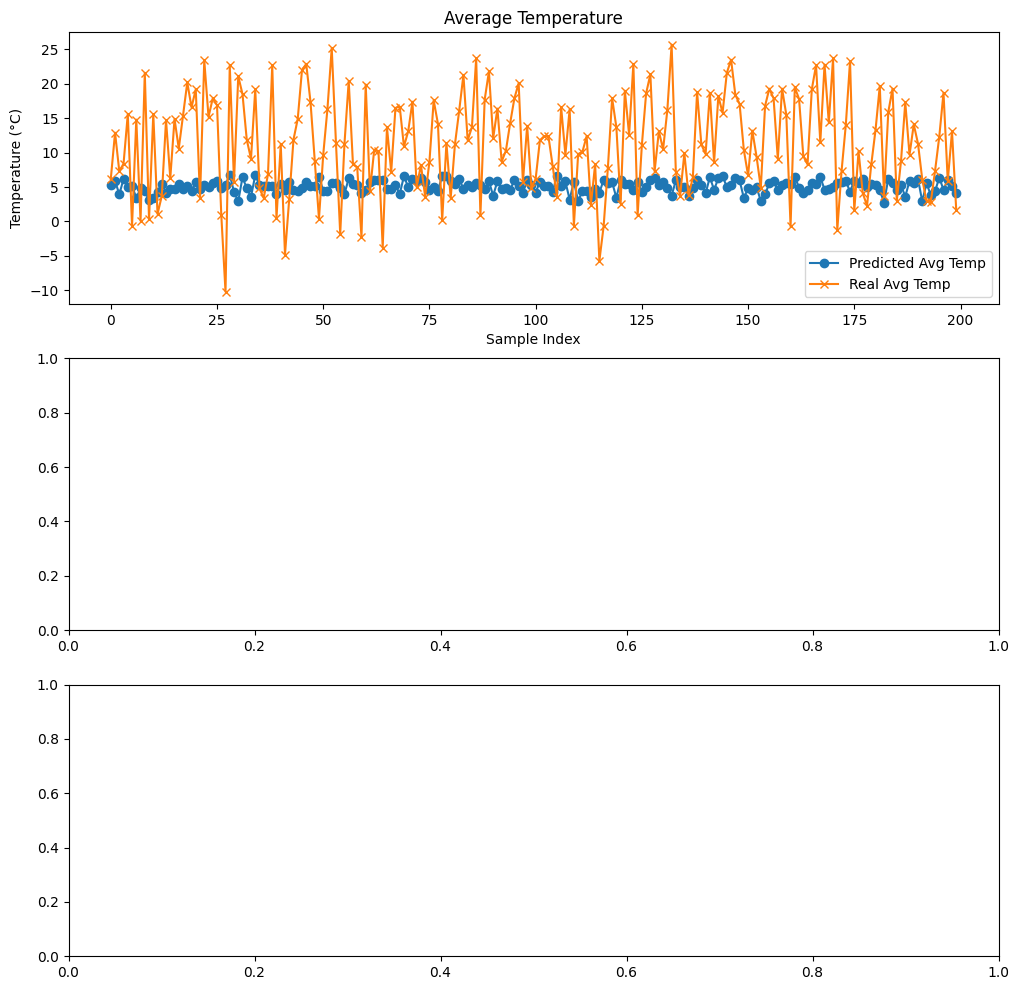

In [22]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


List_of_Samples = []
for k in range (dataset.__len__()):
    Sample = dataset.__getitem__(k)
    List_of_Samples.append(Sample)

# Extract entries (X) and results (y)
entries = [sample[0] for sample in List_of_Samples]  # Extract entries
results = [sample[1] for sample in List_of_Samples]  # Extract results

# Split data into training and testing sets
entries_train, entries_test, results_train, results_test = train_test_split(
    entries, results, test_size=0.2, random_state=42
)

# Convert lists to NumPy arrays for compatibility with Keras
entries_train = np.array(entries_train)
entries_test = np.array(entries_test)
results_train = np.array(results_train)
results_test = np.array(results_test)

# Reshape data to match LSTM input requirements: (samples, timesteps, features)
# Assuming each "entry" is already a sequence, we add a feature dimension
entries_train = entries_train.reshape(entries_train.shape[0], entries_train.shape[1], 1)
entries_test = entries_test.reshape(entries_test.shape[0], entries_test.shape[1], 1)

# Print shapes for verification
print("Train Entries Shape:", entries_train.shape)
print("Train Results Shape:", results_train.shape)

# Build the LSTM model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(entries_train.shape[1], entries_train.shape[2])),
    Dense(10, activation='relu'),
    Dense(results_train.shape[1])  # Output layer with as many units as target values
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
model.fit(entries_train, results_train, epochs=3, batch_size=1, verbose=1)

# Evaluate the model
loss, mae = model.evaluate(entries_test, results_test, verbose=1)
print(f"Test Loss: {loss}, Test MAE: {mae}")

# Select 200 samples
num_samples = 200
predictions = predictions[:num_samples]
results_test = results_test[:num_samples]

# Create subplots for avg, min, and max temperatures
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot avg temperature
axes[0].plot(predictions[:, 0], label="Predicted Avg Temp", marker='o')
axes[0].plot(results_test[:, 0], label="Real Avg Temp", marker='x')
axes[0].set_xlabel("Sample Index")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Average Temperature")
axes[0].legend()

# Plot min temperature
axes[1].plot(predictions[:, 1], label="Predicted Min Temp", marker='o')
axes[1].plot(results_test[:, 1], label="Real Min Temp", marker='x')
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Minimum Temperature")
axes[1].legend()

# Plot max temperature
axes[2].plot(predictions[:, 2], label="Predicted Max Temp", marker='o')
axes[2].plot(results_test[:, 2], label="Real Max Temp", marker='x')
axes[2].set_xlabel("Sample Index")
axes[2].set_ylabel("Temperature (°C)")
axes[2].set_title("Maximum Temperature")
axes[2].legend()

# Adjust spacing and show the plots
plt.tight_layout()
plt.show()
